In [1]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt
import os
from pathlib import Path
import numpy as np



In [2]:
subject = '2209'
session = 'a14'
modelFolder = "labels_v003_0.5scaling"
# modelFolder = "labels_v007"
project_dir = str(Path(f"/Users/ramzyalmulla/research/smearlab/keypoint_moseq_{subject}_{session}/"))
model_name = '2026_05_27-09_56_45'
config = lambda: kpms.load_config(project_dir)

base_path_str = "/Volumes/CrucialRZA/smearlab/clickbait-loco/thermister/"
sleap_dir = str(Path(f"{base_path_str}{modelFolder}/"))

# sleap_file = str(list(Path(sleap_dir).glob(f"**/*{subject}_{session}.slp"))[0])  # any .slp or .h5 file with predictions for a single video
sleap_file = str(list(Path(sleap_dir).glob(f"**/[0-9]*{subject}_{session}.slp"))[0])  # any .slp or .h5 file with predictions for a single video

video_dir = str(Path(base_path_str+f"*/{session.strip('_raw')}/"))  # any directory containing videos (e.g. .mp4, .avi) and/or sleap files with predictions for those videos
if not os.path.exists(project_dir):
    kpms.setup_project(project_dir, sleap_file=sleap_file,video_dir=video_dir) 

In [ ]:
from sklearn.metrics import mutual_info_score
import h5py

def calculate_mi_across_iterations(model_dir):
    checkpoint_path = os.path.join(model_dir, "checkpoint.h5")
    
    with h5py.File(checkpoint_path, "r") as f:
        # Keypoint-MoSeq model snapshots are keyed by iteration number strings
        iterations = sorted([int(k) for k in f["model_snapshots"].keys()])
        
        mask = None
        if "data/mask" in f:
            mask = f["data/mask"][()]
            
        mis = []
        iter_nums = []
        prev_z = None
        
        for it in iterations:
            # Latent states (syllable assignments) are stored under states/z
            z = f[f"model_snapshots/{it}/states/z"][()]
            
            if prev_z is not None:
                if mask is not None:
                    # Account for potential temporal padding mismatches between mask and z
                    slices = tuple(slice(0, s) for s in z.shape)
                    m = mask[slices] == 1
                    z_valid = z[m]
                    prev_z_valid = prev_z[m]
                else:
                    z_valid = z.flatten()
                    prev_z_valid = prev_z.flatten()
                
                mi = mutual_info_score(prev_z_valid, z_valid)
                mis.append(mi)
                iter_nums.append(it)
                
            prev_z = z
            
    # Plot formatting and saving
    plt.figure(figsize=(8, 5))
    plt.plot(iter_nums, mis, marker='o', linestyle='-')
    plt.xlabel("Iteration #")
    plt.ylabel("Mutual Information")
    plt.title("Mutual Information vs. Previous Checkpoint Iteration")
    plt.grid(True)
    
    plot_path = os.path.join(model_dir, "mi_across_iterations.png")
    plt.savefig(plot_path)
    plt.close()
    
    return np.array(mis)

In [6]:
mi_scores = calculate_mi_across_iterations(project_dir, model_name)

In [7]:
mi_scores

array([0.76603057, 1.05880865, 1.13466066, 1.18872042, 1.19922754,
       1.20485938, 1.21419688, 1.22482977, 1.22970628, 1.24646212,
       1.23739292, 1.2485887 , 1.2608981 , 1.25227806, 1.27008182,
       1.26677285, 1.27588524, 1.27676742, 1.27895851, 1.28316932])

In [4]:
# load data 
keypoint_data_path = [str(i) for i in list(Path(sleap_dir).glob(f"**/[0-9]*{session}.slp"))]  # can be a file, a directory, or a list of files
coordinates, confidences, bodyparts = kpms.load_keypoints(keypoint_data_path, "sleap")

Loading keypoints: 100%|██████████████████| 3/3 [00:04<00:00,  1.54s/it]


In [6]:

coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    project_dir,
    overwrite=False,
    **config()
)


In [8]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

In [13]:
import jax_moseq
data = jax_moseq.utils.debugging.convert_data_precision(data)


In [39]:
# load the most recent model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name)

# modify a saved checkpoint so syllables are ordered by frequency
kpms.reindex_syllables_in_checkpoint(project_dir, model_name);

# extract results
results = kpms.extract_results(model, metadata, project_dir, model_name)

Reindexing: 100%|███████████| 21/21 [00:01<00:00, 18.52model snapshot/s]

Saved results to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_
2209_a14/2026_05_26-12_01_57/results.h5


Saving trajectory plots to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_a14/2026_05_26-12_01_57/trajectory_plots


Generating trajectory plots: 100%|██████| 16/16 [00:02<00:00,  5.50it/s]


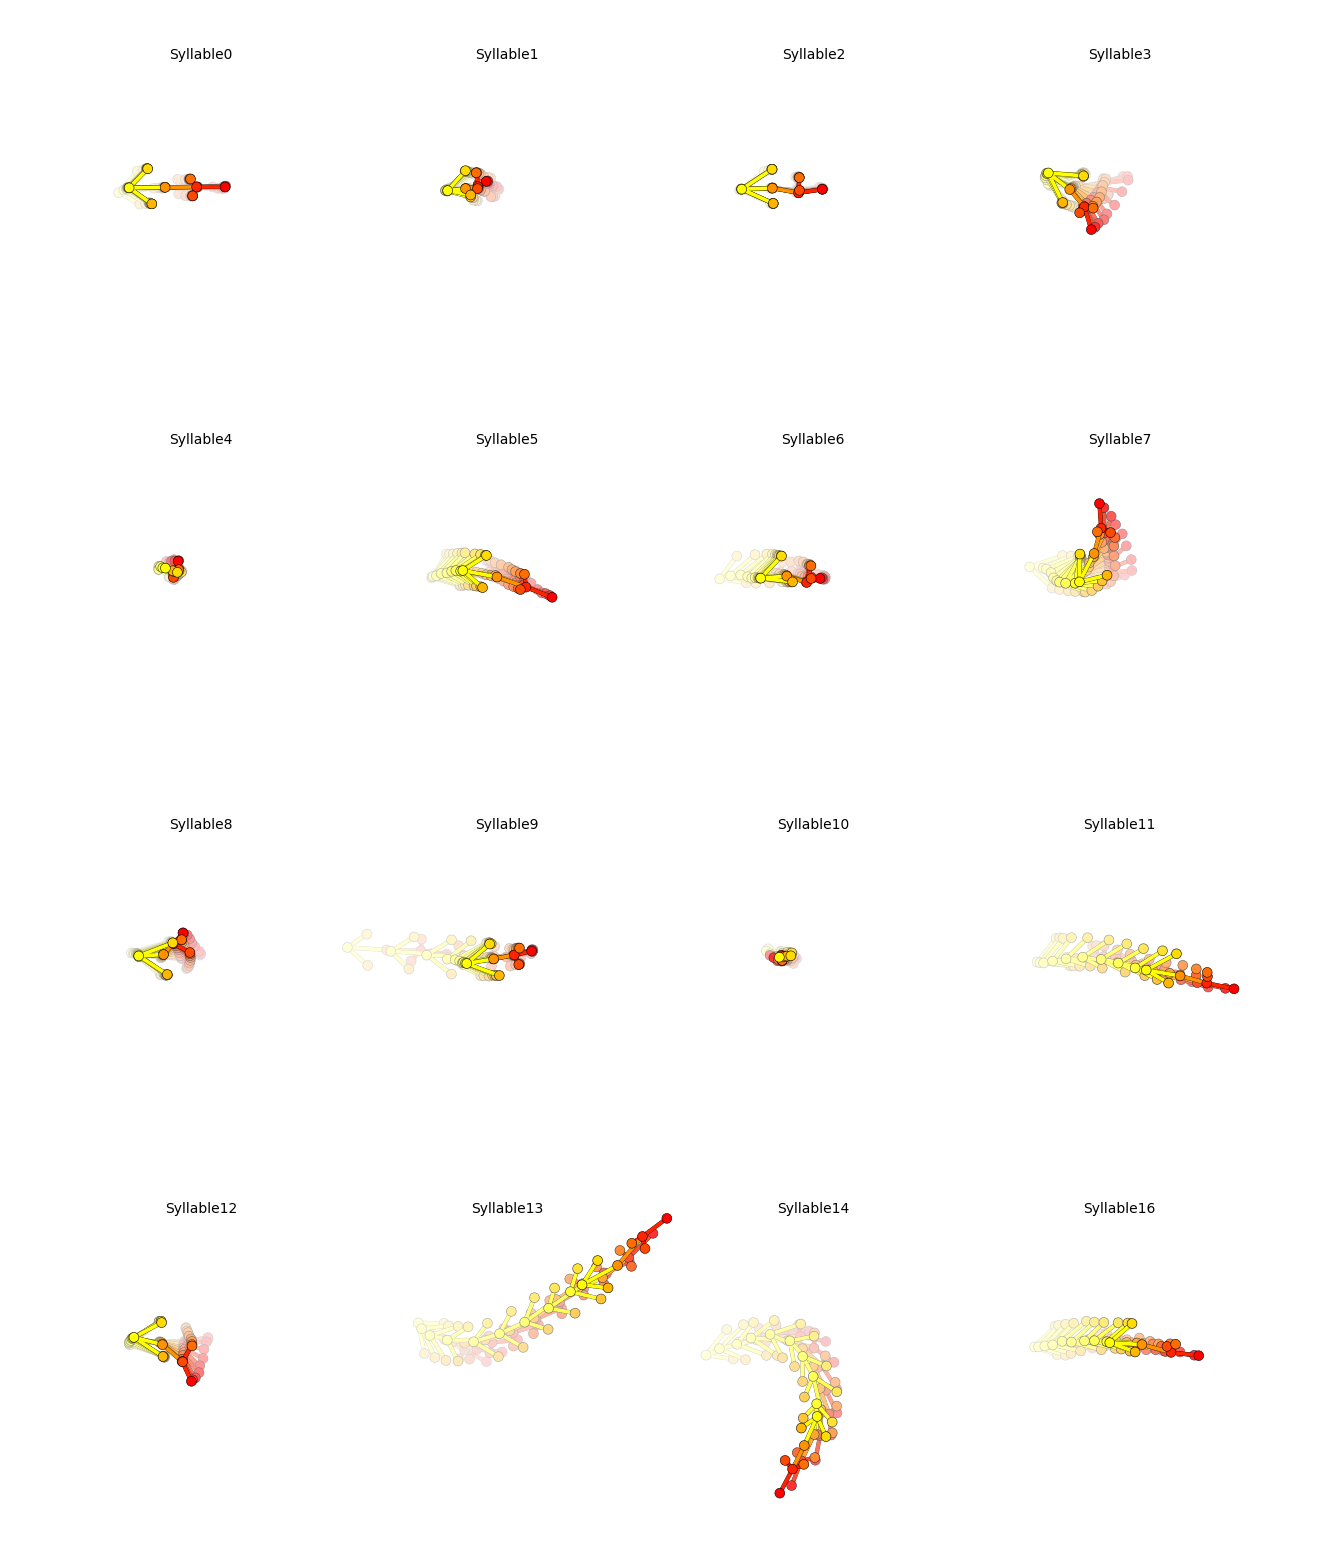

In [40]:
# results = kpms.load_results(project_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, 
                               project_dir, model_name, 
                               **config())


Saving dendrogram plot to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_a14/2026_05_26-12_01_57/similarity_dendrogram


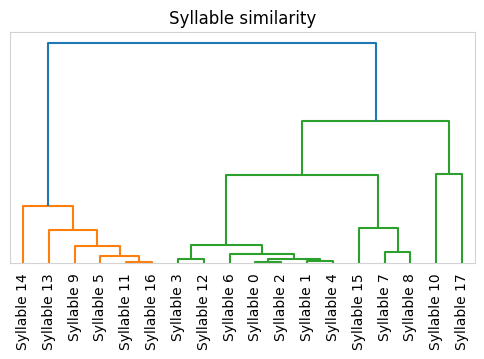

In [41]:
kpms.plot_similarity_dendrogram(coordinates, results, project_dir, model_name,**config())

In [42]:
video_dir = str(Path(base_path_str))  # any directory containing videos (e.g. .mp4, .avi) and/or sleap files with predictions for those videos
kpms.update_config(project_dir,video_dir=video_dir)

In [43]:
kpms.save_results_as_csv(results,project_dir,model_name)

Saving to csv: 100%|██████████████████████| 3/3 [00:00<00:00,  5.80it/s]


In [45]:

kpms.generate_grid_movies(results, project_dir, model_name, 
                          coordinates=coordinates, overlay_keypoints=True, **config());

Writing grid movies to /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_a14/2026_05_26-12_01_57/grid_movies



Videos will be downscaled by a factor of 0.65 so that the grid movies
are under 1920 pixels. Use `max_video_size` to increase or decrease
this size limit.



Using window size of 496 pixels


Generating grid movies: 100%|███████████| 18/18 [02:55<00:00,  9.74s/it]os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


In [4]:
results= kpms.load_results(project_dir,model_name)

In [46]:
import umap
plt.cm

<module 'matplotlib.cm' from '/Users/ramzyalmulla/miniforge3/envs/kpms/lib/python3.10/site-packages/matplotlib/cm.py'>

In [47]:
import matplotlib as mpl

In [68]:
def generate_session_umaps(results: dict, project_dir: str, model_name: str):
    """
    Computes and saves a static 2D UMAP scatter plot for each session 
    in the keypoint-MoSeq results dictionary.
    """
    out_dir = Path(project_dir) / model_name / "umaps" 
    out_dir.mkdir(parents=True, exist_ok=True)

    
    latentsAll = np.concatenate([results[key]['latent_state'] for key in results],axis=0)
    nFramesEachSession = np.array([results[key]['latent_state'].shape[0] for key in results])
    cumFramesEachSession = np.array([0]+[np.sum(nFramesEachSession[:i+1]) for i in range(len(nFramesEachSession)-1)])

    print(f"[INFO] Computing UMAP ({len(latentsAll)} frames)...")
    reducer = umap.UMAP(n_components=2, random_state=42)
    u_emb = reducer.fit_transform(latentsAll)
    ylims = [np.min(u_emb[:,1]),np.max(u_emb[:,1])]
    xlims = [np.min(u_emb[:,0]),np.max(u_emb[:,0])]
    
    for inds, (session_key, data) in enumerate(results.items()):
        if 'latent_state' not in data or 'syllable' not in data:
            print(f"[WARN] Missing latents or syllables for {session_key}. Skipping.")
            continue
            
        syllables = data['syllable']
        u_embThisSession = u_emb[cumFramesEachSession[inds]:cumFramesEachSession[inds]+nFramesEachSession[inds],:]
        
        
        plt.figure(figsize=(10, 8), facecolor="white")
        unique_syls = np.unique(syllables)
        unique_syls = unique_syls[unique_syls >= 0]
        
        colors = np.vstack([mpl.colormaps['tab20'].colors,
                            mpl.colormaps['tab20b'].colors,
                            mpl.colormaps['Pastel1'].colors,
                            mpl.colormaps['Pastel2'].colors])
        
        cmap = mpl.colors.ListedColormap(colors)
        

        scatter = plt.scatter(
            u_embThisSession[:, 0], 
            u_embThisSession[:, 1], 
            c= syllables, 
            cmap=cmap, 
            s=8, 
            vmin=0,
            vmax=colors.shape[0],
            alpha=0.7, 
            edgecolors="none"
        )
        plt.xlim(xlims)
        plt.ylim(ylims)
        
        # Pass unique_syls to the 'num' parameter to force a handle for every syllable
        handles, _ = scatter.legend_elements(prop="colors", alpha=1, num=len(unique_syls))
        labels = [f"Syl {s}" for s in unique_syls]
        
        maxN=colors.shape[0]
        if len(handles) > maxN:
            handles, labels = handles[:maxN], labels[:maxN]
            labels[-1] = "..."
            
            
        plt.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.15, 1), fontsize=8, ncol=1)
        plt.title(f"UMAP Latent Space - {session_key}")
        plt.axis("off")
        plt.tight_layout()
        
        out_file = out_dir / f"{session_key}_umap.png"
        plt.savefig(out_file, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"[INFO] Saved {out_file}")

In [69]:
np.vstack([mpl.colormaps['tab20'].colors,
                            mpl.colormaps['tab20b'].colors,
                            mpl.colormaps['Pastel1'].colors,
                            mpl.colormaps['Pastel2'].colors]).shape

(57, 3)

In [70]:
generate_session_umaps(results,project_dir,model_name)

[INFO] Computing UMAP (164476 frames)...


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

[INFO] Saved /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_a14/2026_05_27-09_56_45/umaps/05152026_2208_a14_umap.png
[INFO] Saved /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_a14/2026_05_27-09_56_45/umaps/05152026_2209_a14_umap.png
[INFO] Saved /Users/ramzyalmulla/research/smearlab/keypoint_moseq_2209_a14/2026_05_27-09_56_45/umaps/05152026_2210_a14_umap.png


In [22]:
np.concatenate([results[key]['latent_state'] for key in results],axis=0).shape

(164476, 8)

In [39]:
unique_syls = np.unique(results['05152026_2208_a14']['syllable'])

In [40]:
unique_syls[unique_syls >= 0]

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18])

In [25]:
[results[key]['latent_state'].shape[0] for key in results]

[54838, 54826, 54812]

In [26]:
nFramesEachSession = np.array([results[key]['latent_state'].shape[0] for key in results])
cumFramesEachSession = np.array([0]+[np.sum(nFramesEachSession[:i+1]) for i in range(len(nFramesEachSession)-1)])

In [27]:
nFramesEachSession

array([54838, 54826, 54812])

In [28]:
cumFramesEachSession

array([     0,  54838, 109664])

In [29]:
109664+54812

164476

In [8]:
project_dir = '/Volumes/CrucialRZA/smearlab/models/kpms_outputs/rslds_keypoint_moseq_30b'
model_names = [f'param_sweep_lW{i}-lb{j}' for i in np.logspace(-4,2,7) for j in np.logspace(-4,2,7)]

In [9]:
mi_scores = [calculate_mi_across_iterations(project_dir,model) for model in model_names]

In [11]:
project_dir = '/Volumes/CrucialRZA/smearlab/models/kpms_outputs/keypoint_moseq_30'
model_name = '2026_06_08-18_44_04'
mi_scores = calculate_mi_across_iterations(project_dir,model_name)

In [17]:
model_dirs = {'rslds'   :   '/Volumes/CrucialRZA/smearlab/models/kpms_outputs/rslds_keypoint_moseq_30/2026_06_07-22_24_34',
              'slds'    :   '/Volumes/CrucialRZA/smearlab/models/kpms_outputs/keypoint_moseq_30/2026_06_08-18_44_04'}

mi_scores = {model:calculate_mi_across_iterations(model_dirs[model]) for model in model_dirs}

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score

def compare_mi_across_iterations(checkpoint_paths, model_labels=None, save_path="mi_across_iterations.png"):
    plt.figure(figsize=(8, 5))
    all_mis = []

    for indp,path in enumerate(checkpoint_paths):
        with h5py.File(path, "r") as f:
            iterations = sorted([int(k) for k in f["model_snapshots"].keys()])
            
            mask = None
            if "data/mask" in f:
                mask = f["data/mask"][()]
                
            mis = []
            iter_nums = []
            prev_z = None
            
            for it in iterations:
                z = f[f"model_snapshots/{it}/states/z"][()]
                
                if prev_z is not None:
                    if mask is not None:
                        slices = tuple(slice(0, s) for s in z.shape)
                        m = mask[slices] == 1
                        z_valid = z[m]
                        prev_z_valid = prev_z[m]
                    else:
                        z_valid = z.flatten()
                        prev_z_valid = prev_z.flatten()
                    
                    mi = mutual_info_score(prev_z_valid, z_valid)
                    mis.append(mi)
                    iter_nums.append(it)
                    
                prev_z = z
                
        all_mis.append(np.array(mis))
        
        # Use the parent directory name (model_name) for the legend
        if model_labels is None:
            model_label = os.path.basename(os.path.dirname(path))
        else:
            try:
                model_label = model_labels[indp]
            except:
                model_label = os.path.basename(os.path.dirname(path))
                
        if not model_label:
            model_label = path
            
        plt.plot(iter_nums, mis, marker='o', linestyle='-', label=model_label)

    plt.xlabel("Iteration #")
    plt.ylabel("Mutual Information")
    plt.title("Mutual Information vs. Previous Checkpoint Iteration")
    plt.legend()
    plt.grid(True)
    
    if save_path:
        plt.savefig(save_path)
    
    return all_mis

In [23]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from scipy.stats import entropy

def get_empirical_metrics(z, num_states):
    """Calculates state probability distribution and transition matrix."""
    counts = np.bincount(z, minlength=num_states)
    probs = counts / np.sum(counts)
    
    T = np.zeros((num_states, num_states))
    np.add.at(T, (z[:-1], z[1:]), 1)
    row_sums = T.sum(axis=1, keepdims=True)
    T = np.divide(T, row_sums, out=np.zeros_like(T), where=row_sums!=0)
    
    return probs, T

def analyze_moseq_convergence(checkpoint_paths, model_labels=None,save_prefix="convergence"):
    # Initialize data structures to hold metrics for all models
    all_metrics = {}
    
    fig, axes = plt.subplots(5, 1, figsize=(10, 24))
    
    for indp,path in enumerate(checkpoint_paths):
        # Use the parent directory name (model_name) for the legend
        if model_labels is None:
            model_label = os.path.basename(os.path.dirname(path))
        else:
            try:
                model_label = model_labels[indp]
            except:
                model_label = os.path.basename(os.path.dirname(path))
        all_metrics[model_label] = {
            'iters': [], 'syllables': [], 'mis': [], 
            'delta_mis': [], 'kl_divs': [], 'frob_norms': []
        }
        
        with h5py.File(path, "r") as f:
            iterations = sorted([int(k) for k in f["model_snapshots"].keys()])
            all_metrics[model_label]['iters'] = iterations
            
            mask = f["data/mask"][()] if "data/mask" in f else None
            prev_z_valid = None
            
            for it in iterations:
                z = f[f"model_snapshots/{it}/states/z"][()]
                
                if mask is not None:
                    slices = tuple(slice(0, s) for s in z.shape)
                    z_valid = z[mask[slices] == 1]
                else:
                    z_valid = z.flatten()
                    
                all_metrics[model_label]['syllables'].append(len(np.unique(z_valid)))
                
                if prev_z_valid is not None:
                    # Mutual Information
                    mi = mutual_info_score(prev_z_valid, z_valid)
                    all_metrics[model_label]['mis'].append(mi)
                    
                    # Ensure dimensions match for KL and Frobenius norm
                    max_state = max(np.max(z_valid), np.max(prev_z_valid)) + 1
                    p_curr, T_curr = get_empirical_metrics(z_valid, max_state)
                    p_prev, T_prev = get_empirical_metrics(prev_z_valid, max_state)
                    
                    # State Distribution KL Divergence
                    eps = 1e-10 # Prevent log(0)
                    kl = entropy(p_curr + eps, p_prev + eps)
                    all_metrics[model_label]['kl_divs'].append(kl)
                    
                    # Transition Matrix Stabilization (Frobenius Norm)
                    frob = np.linalg.norm(T_curr - T_prev, ord='fro')
                    all_metrics[model_label]['frob_norms'].append(frob)
                    
                prev_z_valid = z_valid
                
        # Calculate Delta MI
        all_metrics[model_label]['delta_mis'] = np.diff(all_metrics[model_label]['mis']).tolist()

        # Plotting arrays
        iters = np.array(iterations)
        
        axes[0].plot(iters, all_metrics[model_label]['syllables'], marker='o', label=model_label)
        axes[1].plot(iters[1:], all_metrics[model_label]['mis'], marker='o', label=model_label)
        axes[2].plot(iters[2:], all_metrics[model_label]['delta_mis'], marker='o', label=model_label)
        axes[3].plot(iters[1:], all_metrics[model_label]['kl_divs'], marker='o', label=model_label)
        axes[4].plot(iters[1:], all_metrics[model_label]['frob_norms'], marker='o', label=model_label)

    # Format Plots
    plot_configs = [
        (axes[0], "Active Syllable Count", "Iteration #", "Total Unique States"),
        (axes[1], "Absolute Mutual Information", "Iteration #", "MI Score"),
        (axes[2], "Change in Mutual Information (Δ MI)", "Iteration #", "Δ MI"),
        (axes[3], "State Distribution Shift (KL Divergence)", "Iteration #", "KL Divergence"),
        (axes[4], "Transition Matrix Stabilization (Frobenius Norm)", "Iteration #", "Frobenius Norm")
    ]

    for ax, title, xlabel, ylabel in plot_configs:
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.savefig(f"{save_prefix}_metrics.png")
    plt.close()
    
    return all_metrics

In [50]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score 
from scipy.stats import entropy

def get_empirical_metrics(z, num_states):
    """Calculates state probability distribution and transition matrix."""
    counts = np.bincount(z, minlength=num_states)
    probs = counts / np.sum(counts)
    
    T = np.zeros((num_states, num_states))
    np.add.at(T, (z[:-1], z[1:]), 1)
    row_sums = T.sum(axis=1, keepdims=True)
    T = np.divide(T, row_sums, out=np.zeros_like(T), where=row_sums!=0)
    
    return probs, T

def analyze_moseq_convergence(checkpoint_paths, model_labels=None, save_prefix="convergence", fontsize=18):
    all_metrics = {}
    
    # Extract data for all checkpoints
    for i, path in enumerate(checkpoint_paths):
        # Apply custom label if provided, otherwise default to directory name/path
        model_label = model_labels[i] if model_labels else (os.path.basename(os.path.dirname(path)) or path)
        all_metrics[model_label] = {
            'iters': [], 'syllables': [], 'mis': [], 
            'delta_mis': [], 'kl_divs': [], 'frob_norms': []
        }
        
        with h5py.File(path, "r") as f:
            iterations = sorted([int(k) for k in f["model_snapshots"].keys()])
            all_metrics[model_label]['iters'] = iterations
            
            mask = f["data/mask"][()] if "data/mask" in f else None
            prev_z_valid = None
            
            for it in iterations:
                z = f[f"model_snapshots/{it}/states/z"][()]
                
                if mask is not None:
                    slices = tuple(slice(0, s) for s in z.shape)
                    z_valid = z[mask[slices] == 1]
                else:
                    z_valid = z.flatten()
                    
                all_metrics[model_label]['syllables'].append(len(np.unique(z_valid)))
                
                if prev_z_valid is not None:
                    mi = normalized_mutual_info_score(prev_z_valid, z_valid)
                    all_metrics[model_label]['mis'].append(mi)
                    
                    max_state = max(np.max(z_valid), np.max(prev_z_valid)) + 1
                    p_curr, T_curr = get_empirical_metrics(z_valid, max_state)
                    p_prev, T_prev = get_empirical_metrics(prev_z_valid, max_state)
                    
                    eps = 1e-10 
                    kl = entropy(p_curr + eps, p_prev + eps)
                    all_metrics[model_label]['kl_divs'].append(kl)
                    
                    frob = np.linalg.norm(T_curr - T_prev, ord='fro')
                    all_metrics[model_label]['frob_norms'].append(frob)
                    
                prev_z_valid = z_valid
                
        all_metrics[model_label]['delta_mis'] = np.diff(all_metrics[model_label]['mis']).tolist()

    # Configurations for individual plots (key, title, xlabel, ylabel, filename suffix, index offset)
    plot_configs = [
        ('syllables', "Active Syllable Count", "Iteration #", "Total Unique States", "active_syllables", 0),
        ('mis', "Normalized Mutual Information", "Iteration #", "MI Score", "absolute_mi", 1),
        ('delta_mis', "Change in Mutual Information (Δ MI)", "Iteration #", "Δ MI", "delta_mi", 2),
        ('kl_divs', "State Distribution Shift (KL Divergence)", "Iteration #", "KL Divergence", "kl_divergence", 1),
        ('frob_norms', "Transition Matrix Stabilization (Frobenius Norm)", "Iteration #", "Frobenius Norm", "frob_norm", 1)
    ]

    # Generate and save each plot separately
    for key, title, xlabel, ylabel, filename_suffix, offset in plot_configs:
        plt.figure(figsize=(8, 5))
        
        for label, metrics in all_metrics.items():
            iters = np.array(metrics['iters'])
            # Offset aligns the x-axis properly (e.g., delta_mis is 2 elements shorter than iters)
            plot_iters = iters[offset:] if offset > 0 else iters
            plt.plot(plot_iters, metrics[key], marker='o', label=label)
            
        plt.title(title, fontsize=fontsize)
        plt.xlabel(xlabel, fontsize=fontsize)
        plt.ylabel(ylabel, fontsize=fontsize)
        
        if key == 'mis':
            plt.ylim([min(min(metrics[key])-0.1,0.5),1])
        # Scale down ticks and legend by 4
        plt.tick_params(axis='both', labelsize=fontsize - 4)
        plt.legend(fontsize=fontsize - 4)
        plt.grid(True)
        plt.tight_layout()
        
        save_path = f"{save_prefix}_{filename_suffix}.png"
        plt.savefig(save_path)
        plt.close()
        
    return all_metrics

In [51]:
checkpoints = [
    '/Volumes/CrucialRZA/smearlab/models/kpms_outputs/rslds_keypoint_moseq_30/2026_06_07-22_24_34/checkpoint.h5',
    # '/Volumes/CrucialRZA/smearlab/models/kpms_outputs/rslds_keypoint_moseq_30/2026_06_07-18_48_44/checkpoint.h5',
    '/Volumes/CrucialRZA/smearlab/models/kpms_outputs/keypoint_moseq_30/2026_06_08-18_44_04/checkpoint.h5'
]
labels = ['rslds','slds']
metrics = analyze_moseq_convergence(checkpoints,labels,save_prefix='kpms')

In [52]:
model_names = [[f"param_sweep_lW{j}-lb{i}" for i in np.logspace(-4,2,7)] for j in np.logspace(-4,2,7)]
checkpoints = [
    [f'/Volumes/CrucialRZA/smearlab/models/kpms_outputs/rslds_keypoint_moseq_30b/{model}/checkpoint.h5' for model in model_set] for model_set in model_names
]

# eml_scores, eml_std_errs = kpms.expected_marginal_likelihoods(checkpoint_paths=checkpoints)
# best_model_name = model_names[np.argmax(eml_scores)]
# print(f"Best model: {best_model_name}")

# kpms.plot_eml_scores(eml_scores, eml_std_errs, model_names)
for indw,lw in enumerate(np.logspace(-4,2,7)):
    metrics = analyze_moseq_convergence(checkpoints[indw],[model.replace(f'param_sweep_lW{lw}-','') for model in model_names[indw]],save_prefix=f"lW{lw}")


In [ ]:
checkpoints = [
    '/Volumes/CrucialRZA/smearlab/models/kpms_outputs/rslds_keypoint_moseq_30/2026_06_07-22_24_34/checkpoint.h5',
    '/Volumes/CrucialRZA/smearlab/models/kpms_outputs/rslds_keypoint_moseq_30/2026_06_07-18_48_44/checkpoint.h5',
    '/Volumes/CrucialRZA/smearlab/models/kpms_outputs/keypoint_moseq_30/2026_06_08-18_44_04/checkpoint.h5'
]

model_names = ['rslds1','rslds2','slds']

eml_scores, eml_std_errs = kpms.expected_marginal_likelihoods(checkpoint_paths=checkpoints)
best_model_name = model_names[np.argmax(eml_scores)]
print(f"Best model: {best_model_name}")

kpms.plot_eml_scores(eml_scores, eml_std_errs, model_names)